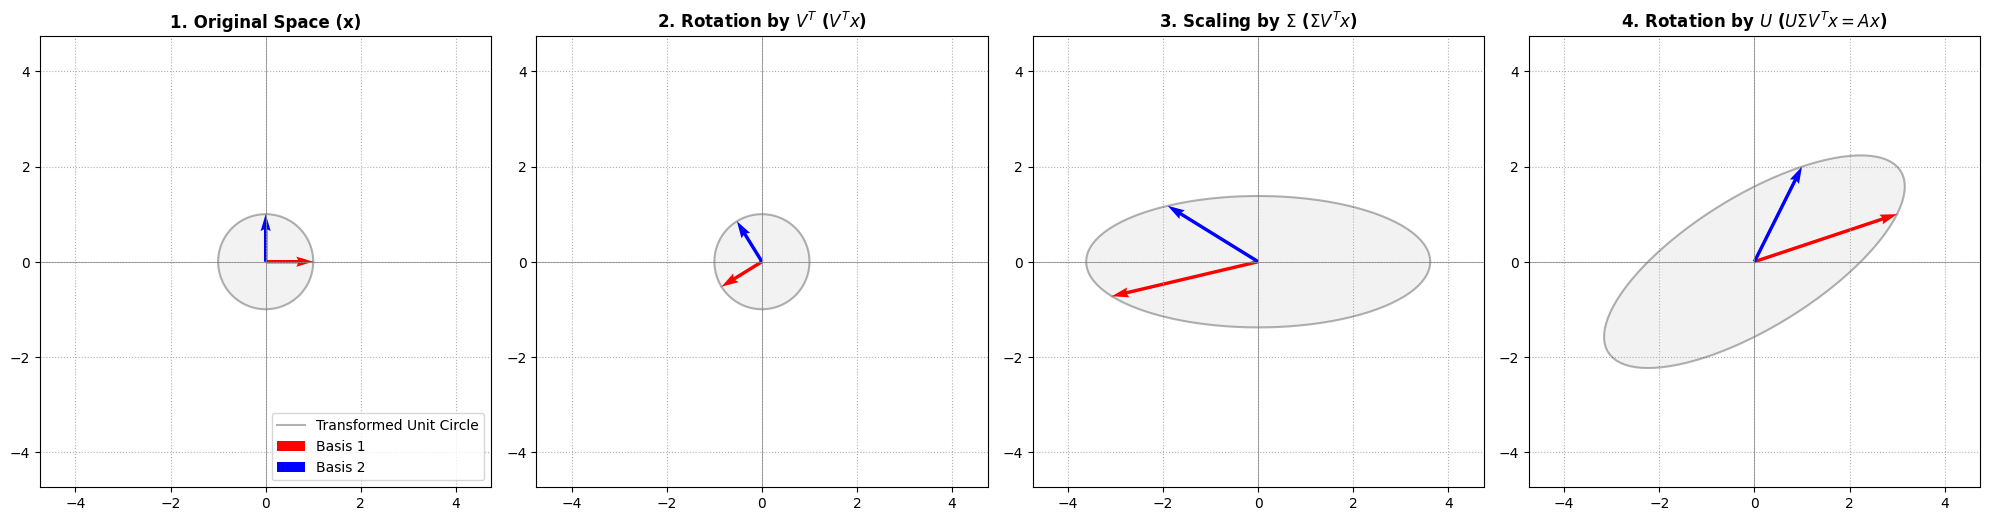

In [1]:
'''
이 코드는 특이값 분해(SVD)를 이용하여 행렬의 선형 변환 과정을 단계별로 시각화합니다.
임의의 2x2 행렬 A를 생성하고, A = U @ Sigma @ Vt 로 분해한 뒤,
입력 공간(단위 원과 기저 벡터)이 회전(Vt) -> 스케일링(Sigma) -> 회전(U)을 거쳐
최종적으로 변환되는 과정을 4개의 서브플롯으로 보여줍니다.
이전 코드와의 차이점: 사용자의 요청에 따라 SVD의 기하학적 의미(회전->확대->회전)를
명확히 보여주기 위해 중간 연산 과정을 분리하여 시각화했습니다.
'''

import numpy as np
import matplotlib.pyplot as plt

def plot_transformation_steps():
    # 1. 시각화할 행렬 A 정의 (예시를 위해 명확한 변환을 주는 행렬 선택)
    # [[3, 1], [1, 2]]와 같은 대칭 행렬이나 일반적인 행렬 모두 가능
    A = np.array([[3, 1], 
                  [1, 2]])

    # 2. 특이값 분해 (SVD) 수행
    # U: 왼쪽 특이 벡터 (회전), S: 특이값 (스케일링), Vt: 오른쪽 특이 벡터의 전치 (회전)
    U, S, Vt = np.linalg.svd(A)
    
    # 대각 행렬 Sigma 생성 (2x2)
    Sigma = np.diag(S)

    # 3. 시각화를 위한 데이터 준비
    # 단위 원 생성 (각도 0 ~ 2pi)
    theta = np.linspace(0, 2*np.pi, 100)
    circle = np.array([np.cos(theta), np.sin(theta)]) # 2 x 100 행렬

    # 표준 기저 벡터 (x축, y축)
    basis_vectors = np.array([[1, 0], [0, 1]]).T # 2 x 2, 열벡터가 기저

    # 색상 설정 (x축 벡터: 빨강, y축 벡터: 파랑)
    colors = ['r', 'b']

    # 4. 단계별 변환 데이터 계산
    
    # Step 1: 원본 (Original)
    step1_circle = circle
    step1_basis = basis_vectors

    # Step 2: V^T 적용 (첫 번째 회전)
    step2_circle = Vt @ circle
    step2_basis = Vt @ basis_vectors

    # Step 3: Sigma 적용 (스케일링) -> 타원으로 변형
    step3_circle = Sigma @ step2_circle
    step3_basis = Sigma @ step2_basis

    # Step 4: U 적용 (두 번째 회전) -> 최종 결과 (A = U @ Sigma @ Vt)
    step4_circle = U @ step3_circle
    step4_basis = U @ step3_basis

    # 5. 시각화 (Subplots 설정)
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    steps_data = [
        (step1_circle, step1_basis, "1. Original Space (x)"),
        (step2_circle, step2_basis, r"2. Rotation by $V^T$ ($V^T x$)"),
        (step3_circle, step3_basis, r"3. Scaling by $\Sigma$ ($\Sigma V^T x$)"),
        (step4_circle, step4_basis, r"4. Rotation by $U$ ($U \Sigma V^T x = Ax$)")
    ]

    # 공통 범위 설정 (최대 스케일에 맞춰 조정)
    max_val = np.max(np.abs(step4_circle)) * 1.5
    
    for i, (circ, vec, title) in enumerate(steps_data):
        ax = axes[i]
        
        # 원/타원 그리기
        ax.plot(circ[0, :], circ[1, :], 'k-', alpha=0.3, label='Transformed Unit Circle')
        ax.fill(circ[0, :], circ[1, :], 'k', alpha=0.05)
        
        # 기저 벡터 그리기 (Quiver 사용)
        # origin (0,0)에서 시작
        ax.quiver(0, 0, vec[0, 0], vec[1, 0], color=colors[0], angles='xy', scale_units='xy', scale=1, label='Basis 1')
        ax.quiver(0, 0, vec[0, 1], vec[1, 1], color=colors[1], angles='xy', scale_units='xy', scale=1, label='Basis 2')

        # 좌표축 및 그리드 설정
        ax.set_xlim(-max_val, max_val)
        ax.set_ylim(-max_val, max_val)
        ax.axhline(0, color='grey', linewidth=0.5)
        ax.axvline(0, color='grey', linewidth=0.5)
        ax.grid(True, linestyle=':')
        ax.set_aspect('equal') # 비율 유지 필수 (회전 왜곡 방지)
        ax.set_title(title, fontsize=12, fontweight='bold')

        # 첫 번째 그래프에만 범례 표시 (공간 절약)
        if i == 0:
            ax.legend(loc='lower right')

    plt.tight_layout()
    plt.show()

# 함수 실행
if __name__ == "__main__":
    plot_transformation_steps()

### 수치적 분해 결과
**Original Matrix A:**
[[3 1]
 [1 2]]

**SVD Components:**
- **U (Rotation):**
[[-0.85065081 -0.52573111]
 [-0.52573111  0.85065081]]
- **Sigma (Scaling):**
[[3.61803399 0.        ]
 [0.         1.38196601]]
- **V^T (Rotation):**
[[-0.85065081 -0.52573111]
 [-0.52573111  0.85065081]]



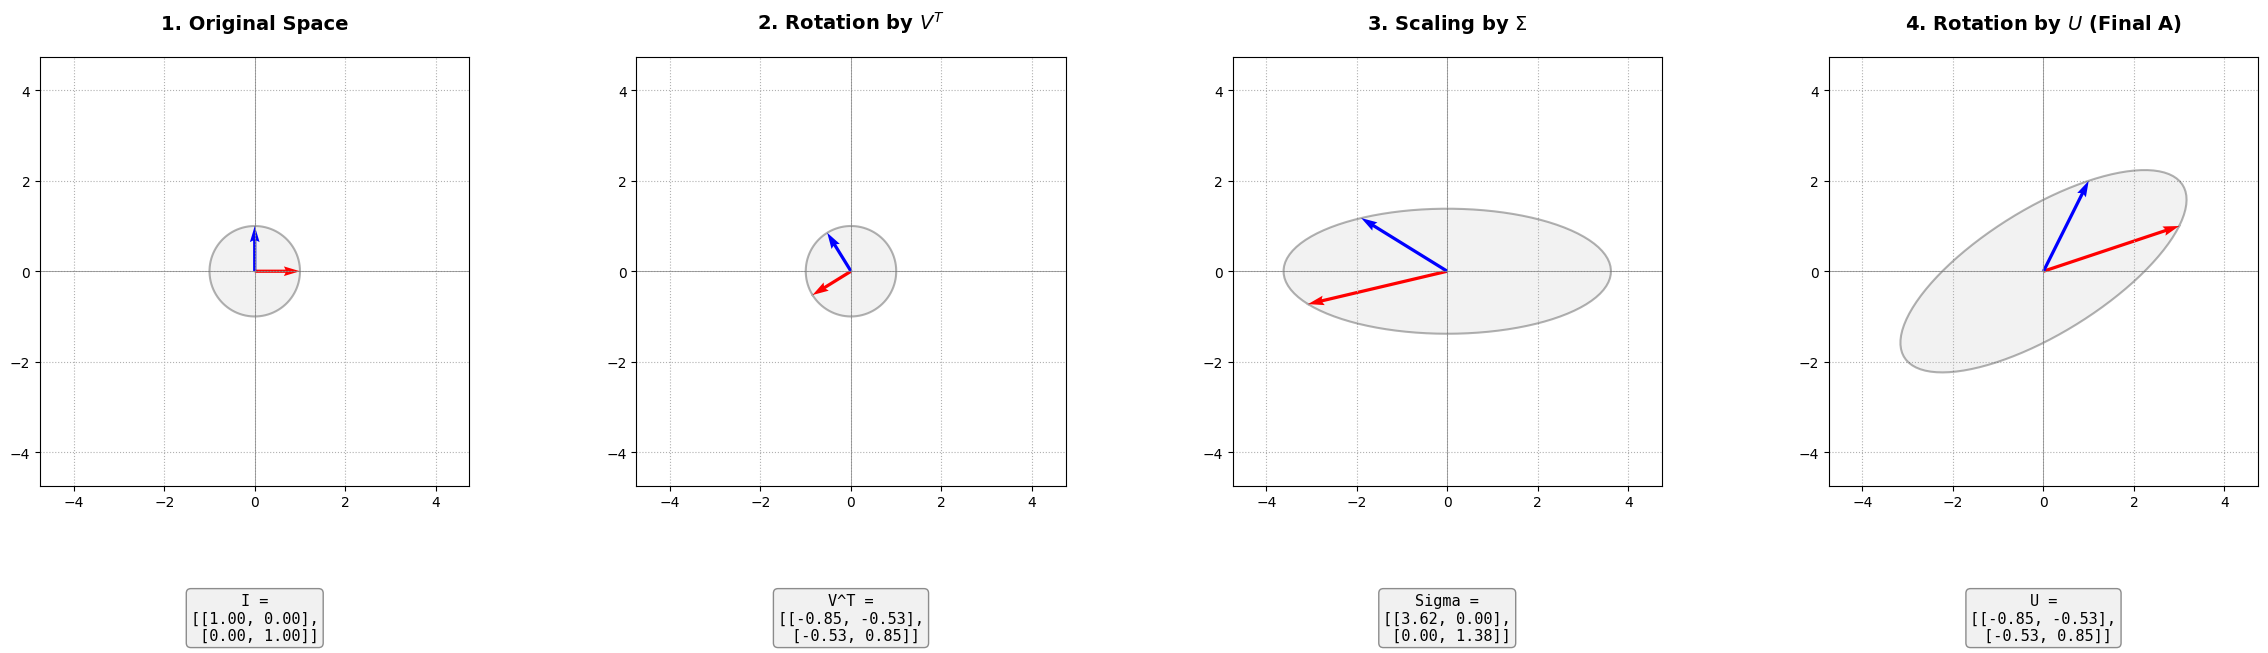

In [2]:
'''
이 코드는 행렬 A의 특이값 분해(SVD) 과정을 시각화하면서, 각 단계에 해당하는 행렬의 수치 값을 그래프와 함께 보여줍니다.
LaTeX 렌더링 오류를 방지하기 위해 행렬 값을 일반 텍스트(Monospace 폰트)로 변환하여 표시합니다.
'''

import numpy as np
import matplotlib.pyplot as plt

def visualize_svd_with_values_v2():
    # 1. 행렬 A 정의 (기존과 동일하게 시각적 효과가 좋은 대칭 행렬 사용)
    A = np.array([[3, 1], 
                  [1, 2]])

    # 2. SVD 수행
    U, S, Vt = np.linalg.svd(A)
    Sigma = np.diag(S)

    # 3. 데이터 준비 (단위 원 및 기저 벡터)
    theta = np.linspace(0, 2*np.pi, 100)
    circle = np.array([np.cos(theta), np.sin(theta)])
    basis = np.array([[1, 0], [0, 1]]).T # 열벡터가 기저

    # 4. 단계별 변환 데이터 계산
    # Step 1: Original
    step1_circle = circle
    step1_basis = basis

    # Step 2: V^T (Rotation 1)
    step2_circle = Vt @ circle
    step2_basis = Vt @ basis

    # Step 3: Sigma (Scaling)
    step3_circle = Sigma @ step2_circle
    step3_basis = Sigma @ step2_basis

    # Step 4: U (Rotation 2)
    step4_circle = U @ step3_circle
    step4_basis = U @ step3_basis

    # 5. 시각화 설정
    fig, axes = plt.subplots(1, 4, figsize=(24, 6))
    
    # 각 단계별 정보: (원 데이터, 기저 데이터, 타이틀, 표시할 행렬 이름, 표시할 행렬 값)
    # 3x3 이하 행렬이므로 직접 계산하여 리스트에 저장
    # Step 2에서 Vt를 사용하므로 Vt를 표시
    # Step 3에서 Sigma를 사용하므로 Sigma를 표시
    # Step 4에서 U를 사용하므로 U를 표시
    
    steps = [
        (step1_circle, step1_basis, "1. Original Space", "I", np.eye(2)),
        (step2_circle, step2_basis, r"2. Rotation by $V^T$", "V^T", Vt),
        (step3_circle, step3_basis, r"3. Scaling by $\Sigma$", "Sigma", Sigma),
        (step4_circle, step4_basis, r"4. Rotation by $U$ (Final A)", "U", U)
    ]

    # 그래프 범위 설정 (최종 결과보다 약간 크게)
    max_limit = np.max(np.abs(step4_circle)) * 1.5

    for i, (circ, vec, title, mat_name, mat_val) in enumerate(steps):
        ax = axes[i]
        
        # 도형 및 벡터 그리기
        ax.plot(circ[0, :], circ[1, :], 'k-', alpha=0.3)
        ax.fill(circ[0, :], circ[1, :], 'k', alpha=0.05)
        ax.quiver(0, 0, vec[0, 0], vec[1, 0], color='r', angles='xy', scale_units='xy', scale=1, label='Basis x')
        ax.quiver(0, 0, vec[0, 1], vec[1, 1], color='b', angles='xy', scale_units='xy', scale=1, label='Basis y')

        # 축 설정
        ax.set_xlim(-max_limit, max_limit)
        ax.set_ylim(-max_limit, max_limit)
        ax.axhline(0, color='grey', linewidth=0.5)
        ax.axvline(0, color='grey', linewidth=0.5)
        ax.grid(True, linestyle=':')
        ax.set_aspect('equal')
        ax.set_title(title, fontsize=14, fontweight='bold', pad=20)

        # 행렬 값 텍스트로 표시 (그래프 하단)
        # 등폭 폰트로 깔끔하게 포맷팅
        mat_str = f"{mat_name} =\n[[{mat_val[0,0]:.2f}, {mat_val[0,1]:.2f}],\n [{mat_val[1,0]:.2f}, {mat_val[1,1]:.2f}]]"
        
        # 텍스트 박스 추가 (그래프 내부 하단, 좌표계 기준이 아니라 축 기준 위치 설정)
        # transform=ax.transAxes를 사용하여 축의 비율 좌표(0~1)를 사용
        ax.text(0.5, -0.25, mat_str, transform=ax.transAxes, 
                fontsize=11, ha='center', va='top', family='monospace',
                bbox=dict(boxstyle='round', facecolor='#f0f0f0', alpha=0.9, edgecolor='grey'))

    plt.tight_layout()
    plt.savefig('svd_visualization_with_values_v2.png')
    
    # 텍스트 출력을 위한 문자열 생성
    result_text = "### 수치적 분해 결과\n"
    result_text += f"**Original Matrix A:**\n{A}\n\n"
    result_text += "**SVD Components:**\n"
    result_text += f"- **U (Rotation):**\n{U}\n"
    result_text += f"- **Sigma (Scaling):**\n{np.diag(S)}\n"
    result_text += f"- **V^T (Rotation):**\n{Vt}\n"
    
    print(result_text)

if __name__ == "__main__":
    visualize_svd_with_values_v2()

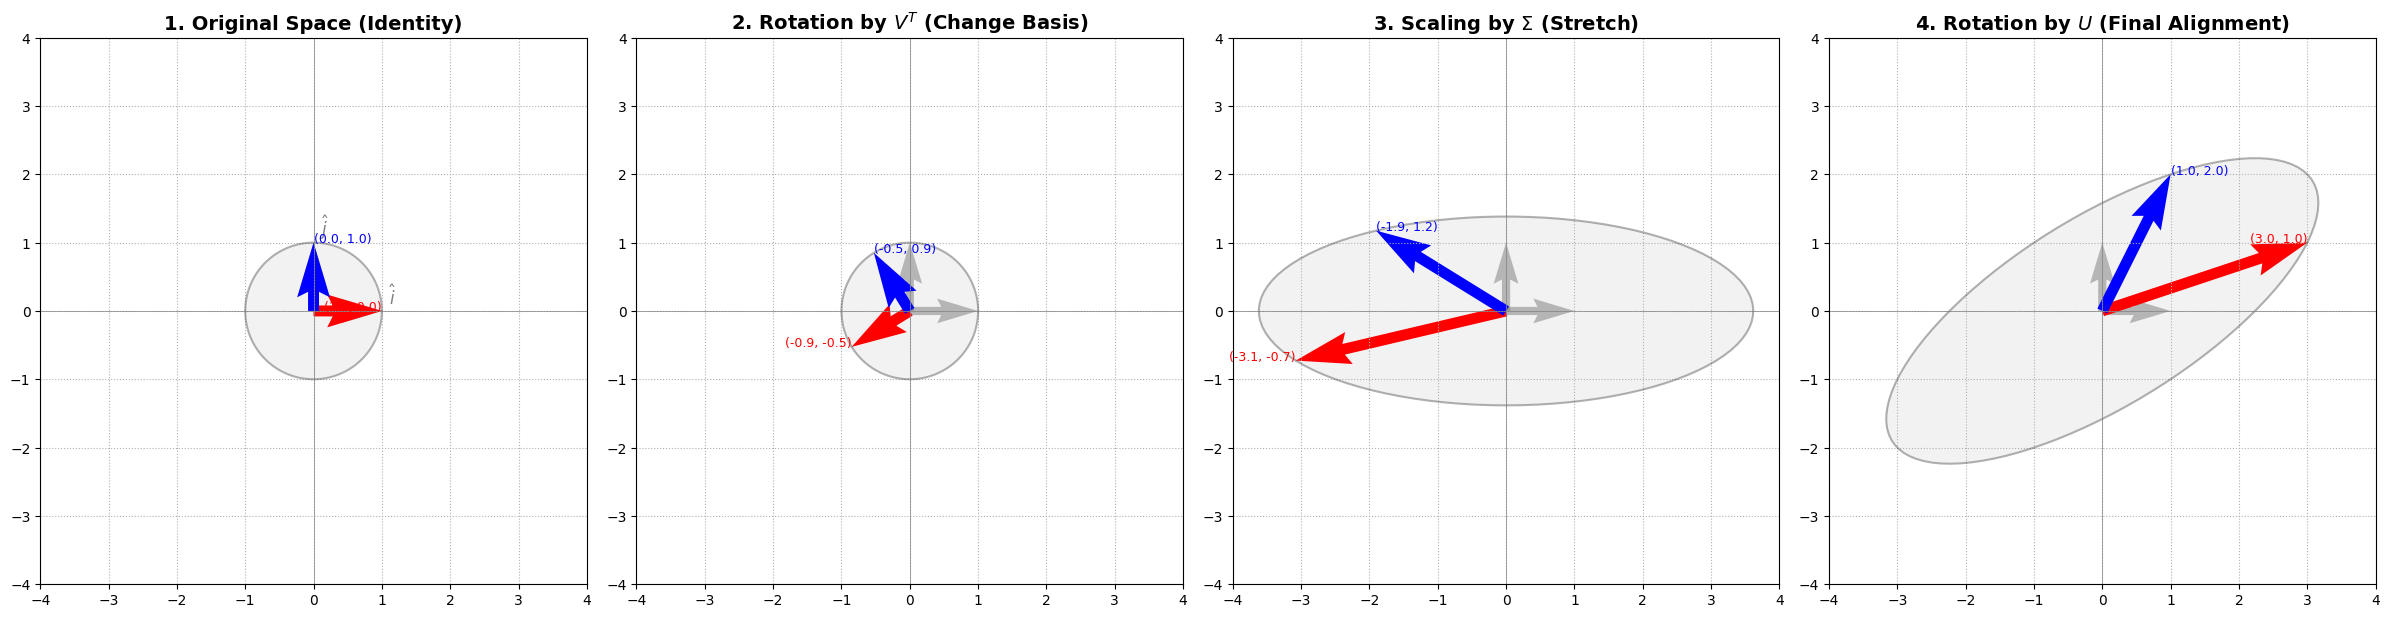

In [3]:
'''
이 코드는 SVD 변환 과정을 시각화하며, 각 단계에서 '고정된 표준 기저(Standard Basis)'와
'변환되는 기저(Transformed Basis)'를 동시에 보여줍니다.
- 회색 점선 화살표: 움직이지 않는 표준 좌표계 (Reference)
- 빨강/파랑 실선 화살표: 행렬에 의해 변환되는 좌표계 (Active)
'''

import numpy as np
import matplotlib.pyplot as plt

def visualize_svd_with_reference():
    # 1. 행렬 A 정의 (대칭행렬 예시)
    A = np.array([[3, 1], 
                  [1, 2]])

    # 2. SVD 수행
    U, S, Vt = np.linalg.svd(A)
    Sigma = np.diag(S)

    # 3. 데이터 준비
    theta = np.linspace(0, 2*np.pi, 100)
    circle = np.array([np.cos(theta), np.sin(theta)])
    
    # 변환될 기저 (Active Basis)
    basis = np.array([[1, 0], [0, 1]]).T 
    
    # 고정된 참조 기저 (Standard Basis) - 변하지 않음
    std_basis = np.array([[1, 0], [0, 1]]).T

    # 4. 단계별 변환 계산
    # Step 1: Original
    step1_circle = circle
    step1_basis = basis

    # Step 2: V^T (Rotation/Reflection)
    step2_circle = Vt @ circle
    step2_basis = Vt @ basis

    # Step 3: Sigma (Scaling)
    step3_circle = Sigma @ step2_circle
    step3_basis = Sigma @ step2_basis

    # Step 4: U (Rotation/Reflection)
    step4_circle = U @ step3_circle
    step4_basis = U @ step3_basis

    # 5. 시각화
    fig, axes = plt.subplots(1, 4, figsize=(24, 6))
    
    steps = [
        (step1_circle, step1_basis, "1. Original Space (Identity)", "I"),
        (step2_circle, step2_basis, r"2. Rotation by $V^T$ (Change Basis)", "V^T"),
        (step3_circle, step3_basis, r"3. Scaling by $\Sigma$ (Stretch)", "Sigma"),
        (step4_circle, step4_basis, r"4. Rotation by $U$ (Final Alignment)", "U")
    ]

    max_limit = 4.0

    for i, (circ, vec, title, mat_name) in enumerate(steps):
        ax = axes[i]
        
        # 1) 고정된 표준 기저 (회색 점선) - 모든 플롯에 동일하게 표시
        ax.quiver(0, 0, std_basis[0, 0], std_basis[1, 0], color='gray', angles='xy', scale_units='xy', scale=1, linestyle='--', alpha=0.5, width=0.015)
        ax.quiver(0, 0, std_basis[0, 1], std_basis[1, 1], color='gray', angles='xy', scale_units='xy', scale=1, linestyle='--', alpha=0.5, width=0.015)
        # 텍스트 라벨 (e1, e2)
        if i == 0: # 첫 번째 플롯에만 라벨 표시 (복잡도 방지)
            ax.text(1.1, 0.1, r'$\hat{i}$', color='gray', fontsize=12)
            ax.text(0.1, 1.1, r'$\hat{j}$', color='gray', fontsize=12)

        # 2) 변환된 기저 (색상 실선) - 주인공
        ax.plot(circ[0, :], circ[1, :], 'k-', alpha=0.3)
        ax.fill(circ[0, :], circ[1, :], 'k', alpha=0.05)
        
        # 빨강(x기반), 파랑(y기반) 화살표
        q1 = ax.quiver(0, 0, vec[0, 0], vec[1, 0], color='r', angles='xy', scale_units='xy', scale=1, width=0.02, label='Basis 1')
        q2 = ax.quiver(0, 0, vec[0, 1], vec[1, 1], color='b', angles='xy', scale_units='xy', scale=1, width=0.02, label='Basis 2')

        # 3) 벡터 좌표 표시 (값이 어떻게 변했는지 확인)
        # 벡터 끝점에 좌표 텍스트 추가
        ax.text(vec[0, 0], vec[1, 0], f"({vec[0,0]:.1f}, {vec[1,0]:.1f})", color='r', fontsize=9, ha='right')
        ax.text(vec[0, 1], vec[1, 1], f"({vec[0,1]:.1f}, {vec[1,1]:.1f})", color='b', fontsize=9, ha='left')

        # 축 설정
        ax.set_xlim(-max_limit, max_limit)
        ax.set_ylim(-max_limit, max_limit)
        ax.axhline(0, color='grey', linewidth=0.5)
        ax.axvline(0, color='grey', linewidth=0.5)
        ax.grid(True, linestyle=':')
        ax.set_aspect('equal')
        ax.set_title(title, fontsize=14, fontweight='bold')

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    visualize_svd_with_reference()